In [1]:
%load_ext autoreload
%autoreload 2
import tensorflow as tf
import numpy as np
import gymnasium as gym

import jlab_opt_control.envs as custom_gym
import jlab_opt_control.agents as agents
import paces.paces_envs as paces_gym
from paces.paces_envs.lcls.utils.rescale_observation import RescaleObservation

import logging
run_openai_log = logging.getLogger("RunOpenAI")
run_openai_log.setLevel(logging.ERROR)
logging.basicConfig(format='%(asctime)s %(levelname)s:%(name)s:%(message)s')

import warnings
warnings.filterwarnings('ignore')

In [34]:
 # Environment
env_id = 'PACES-HeatObj-CEBAF4DEnv-v0'
models_subdir = 'HeatObj-4D'

env_id = 'PACES-MO-CEBAF-HEAT-8D-v0'
models_subdir = 'MO-Heat-8D'
#run_openai_log.info('Running env: {}'.format(env_id))

if env_id in gym.envs.registry:
    env = gym.make(env_id)
elif env_id in custom_gym.list_registered_modules():
    env = custom_gym.make(env_id)
elif 'paces_gym' in globals() and env_id in paces_gym.list_registered_modules():
    env = paces_gym.make(env_id)
    if 'LCLS' in env_id:
        env.set_curriculum_difficulty(difficulty)
        # Check if max_nsteps is not defined, set it to default (10) for lcls env
        if max_nsteps <= 0:
            max_nsteps = 10 
        env = TimeLimit(env, max_nsteps)
        env = RescaleObservation(env, -1, 1)
        env = RescaleAction(env, -1, 1)
        env = FlattenObservation(env)

num_states = env.observation_space.shape[0]
run_openai_log.info("Size of State Space ->  {}".format(num_states))
num_actions = env.action_space.shape[0]
run_openai_log.info("Size of Action Space ->  {}".format(num_actions))

upper_bound = env.action_space.high[0]
lower_bound = env.action_space.low[0]

run_openai_log.info("Max Value of Action ->  {}".format(upper_bound))
run_openai_log.info("Min Value of Action ->  {}".format(lower_bound))

Attempting to load paces.paces_envs with mo_cebaf_env
Type:  C25
Type:  C25
Type:  C25
Type:  C25
Type:  C25
Type:  C25
Type:  C25
Type:  C25
Using min, max energy boundaries as:  12.0 28.175000000000004
Max Gradients:  [5.75 9.   9.2  6.   4.   7.6  6.6  8.2 ]
Min Gradients:  [3. 3. 3. 3. 3. 3. 3. 3.]
Target energy: 20.08
Energy min/max: 19.68/20.479999999999997
Low rewards: [ -1.21038657 -47.02131729]
High rewards: [-6.31026899e-03 -8.26978603e+00]
Initial state: [ 0.8962257   0.23491806 -0.24202874  0.45872673  0.37239566  0.947309
  0.54614127  0.05488153]
Initial Energy: 22.77031036913395


Loading model from checkpoint:  epoch_9999


/Users/jcolen/miniconda3/envs/jlab_opt_control_env/lib/python3.9/site-packages/pysindy/optimizers/sr3.py:390: ConvergenceWarning: SR3._reduce did not converge after 30 iterations.
  warnings.warn(


Q = 0.8 1 + 0.1 G2 + 0.1 G3 + 0.1 G4 + -0.2 G7 + -0.3 G0 G1 + -0.3 G0 G2 + -0.2 G0 G3 + -0.1 G0 G4 + -0.2 G0 G5 + -0.2 G0 G6 + -0.1 G0 G7 + -0.3 G1^2 + -0.8 G1 G2 + -0.4 G1 G3 + -0.2 G1 G4 + -0.5 G1 G5 + -0.4 G1 G6 + -0.6 G1 G7 + -0.4 G2^2 + -0.3 G2 G3 + -0.1 G2 G4 + -0.6 G2 G5 + -0.4 G2 G6 + -0.7 G2 G7 + -0.2 G3 G5 + -0.2 G3 G6 + -0.3 G3 G7 + -0.1 G4 G7 + -0.3 G5^2 + -0.4 G5 G6 + -0.4 G5 G7 + -0.2 G6^2 + -0.4 G6 G7 + -0.3 G7^2 + -0.1 G0^3 + 0.1 G0^2 G1 + 0.2 G0^2 G2 + 0.1 G0 G1 G2 + 0.1 G0 G1 G3 + 0.1 G0 G1 G4 + -0.1 G0 G2^2 + -0.1 G0 G2 G3 + 0.1 G0 G2 G5 + 0.1 G0 G2 G6 + 0.1 G0 G2 G7 + 0.1 G0 G3 G4 + 0.1 G0 G3 G6 + -0.1 G0 G4 G5 + -0.1 G0 G4 G7 + 0.1 G0 G5 G7 + 0.2 G0 G6^2 + -0.2 G0 G6 G7 + 0.1 G0 G7^2 + -0.1 G1^2 G6 + -0.1 G1^2 G7 + -0.1 G1 G2^2 + -0.1 G1 G2 G3 + 0.1 G1 G2 G4 + -0.1 G1 G2 G6 + -0.1 G1 G3 G4 + 0.1 G1 G4 G6 + 0.2 G1 G6 G7 + 0.1 G1 G7^2 + -0.1 G2^3 + -0.1 G2^2 G3 + -0.1 G2^2 G4 + 0.1 G2^2 G6 + 0.1 G2 G3 G5 + 0.1 G2 G3 G6 + 0.1 G2 G3 G7 + 0.1 G2 G4 G6 + 0.2 G2 G4 G7 + -

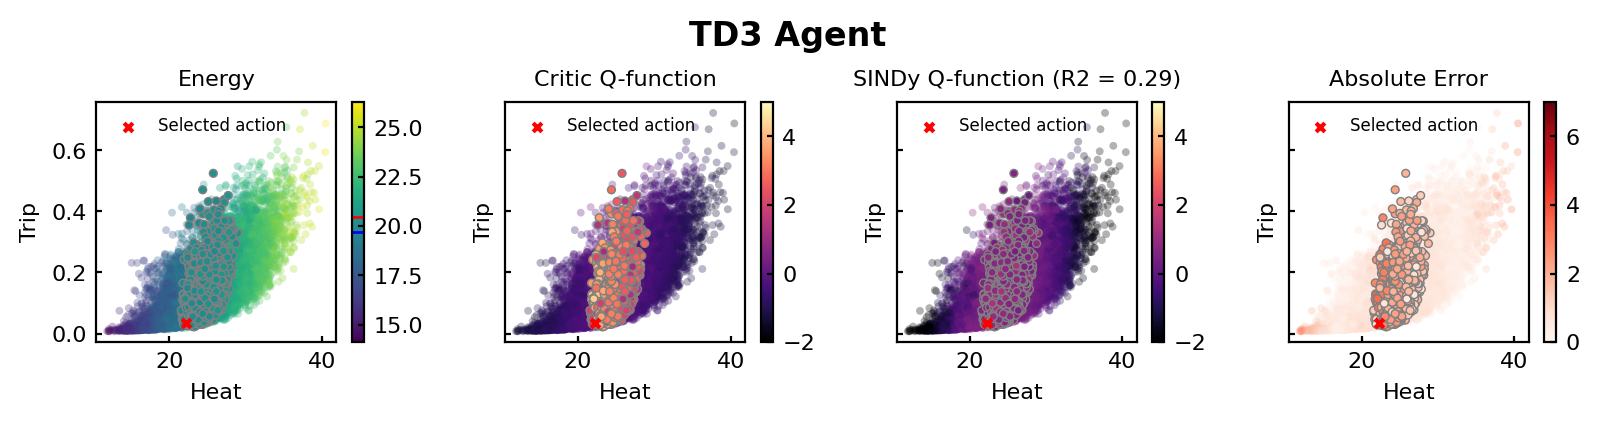

In [55]:
import os
import glob
import jlab_opt_control.agents as agents
import matplotlib.pyplot as plt

plt.rcParams['axes.titlesize'] = 8
plt.rcParams['axes.labelsize'] = 8
plt.rcParams['figure.dpi'] = 200
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 2
plt.rcParams['ytick.major.size'] = 2
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8

logging.getLogger("Agent Registry").setLevel(logging.WARNING)
logging.getLogger("Model Registry").setLevel(logging.WARNING)
logging.getLogger("Env Registry").setLevel(logging.WARNING)
logging.getLogger("Buffer").setLevel(logging.ERROR)
logging.getLogger("CfgLogger").setLevel(logging.ERROR)
logging.getLogger("TD3-Agent").setLevel(logging.ERROR)

# Agent
models_dir = '/Users/jcolen/Documents/rl_opt_control/models/CEBAF/'
agent_id = 'KerasTD3-v0'
logdir = glob.glob(f'{models_dir}/{models_subdir}/*{agent_id}*')[0]

agent = agents.make(
    agent_id, 
    env=env, 
    logdir=logdir, 
    cfg=f'{logdir}/cfgs/keras_td3.cfg'
)

checkpoints = sorted(glob.glob(f'{logdir}/models/epoch_*'))
agent.model_load_path = checkpoints[-1]
print('Loading model from checkpoint: ', os.path.basename(agent.model_load_path))
agent.load()



def plot_states_actions(ax, env, states, actions, color=None, format=True, vmin=None, vmax=None, cmap='viridis'):
    gradients = env.denormalize_state(actions)

    # Get Heat, Energy, and Trip
    heat = np.zeros(N)
    trip = np.zeros(N)
    energy = np.zeros(N)

    for i, cavity in enumerate(env.linac.cavities):
        trip += 3600 * np.exp(-10.268 + cavity.trip_slope * (gradients[:, i] - cavity.trip_offset))
        heat += gradients[:, i]**2 * cavity.length * 1e12 / (cavity.shunt * cavity.Q0)
        energy += gradients[:, i] * cavity.length

    heat_reward = 25 - heat
    heat_reward[heat_reward < 0] = -9 + heat_reward[heat_reward < 0]
    heat_reward = 1. / (heat + 1e-5)

    trip_reward = 0.05 - trip
    trip_reward[trip_reward < 0] = -9 + trip_reward[trip_reward < 0]

    reward = heat_reward
    reward[energy < env.min_energy] -= 10 * np.abs(energy[energy < env.min_energy] - env.target_energy)
    reward[energy > env.max_energy] -= 10 * np.abs(energy[energy > env.max_energy] - env.target_energy)

    plot_energy_bounds = False
    if color is None:
        color = energy
        plot_energy_bounds = True

    # Energy bounds
    mask = (energy >= env.min_energy) & (energy <= env.max_energy)

    kwargs = dict(cmap=cmap, 
                  vmin=np.min(color) if vmin is None else vmin, 
                  vmax=np.max(color) if vmax is None else vmax, 
                  s=8)
    c = ax.scatter(heat[~mask], trip[~mask], c=color[~mask], alpha=0.3, edgecolor='none', **kwargs)
    c = ax.scatter(heat[mask], trip[mask], c=color[mask], edgecolor='grey', linewidths=0.5, **kwargs)

    # Format axis
    if format:
        ax.set(
            xlabel='Heat',
            ylabel='Trip',
            aspect=np.ptp(ax.get_xlim()) / np.ptp(ax.get_ylim()),
        )
        cbar = fig.colorbar(c, ax=ax)
        if plot_energy_bounds:
            cbar.ax.axhline(env.min_energy, color='blue', linewidth=1)
            cbar.ax.axhline(env.max_energy, color='red', linewidth=1)


# Get states and actions
N = 10000
states = np.zeros([N, env.ncavities])
actions = np.random.uniform(size=(N, env.ncavities), low=-1, high=1)
critic_values = agent.critic_model1(states, actions).numpy()

action = agent.actor_model(states[0:1], training=False)
_, _, _, _, info = env.step(action[0])

import pysindy as ps
from sklearn.metrics import r2_score
inputs = actions
targets = critic_values.reshape([-1, 1])

sindy = ps.SINDy(
    feature_library=ps.PolynomialLibrary(degree=3, include_interaction=True),
    optimizer=ps.SR3(threshold=1e-1, nu=1e-1, normalize_columns=True),
    feature_names=[f'G{i:01d}' for i in range(env.ncavities)],
)
sindy.fit(x=inputs, x_dot=targets)
sindy.print(lhs='Q', precision=1)
sindy_values = sindy.predict(inputs)
score = r2_score(targets, sindy_values)
print(f'SINDy model has {np.count_nonzero(sindy.coefficients())} / {sindy.coefficients().size} non-zero coefficients and reaches R2 = {score:.2f}')

vmin, vmax = -2, 5

fig, ax = plt.subplots(1, 4, figsize=(8, 2), constrained_layout=True, sharex=True, sharey=True)

plot_states_actions(ax[0], env, states, actions, cmap='viridis')
ax[0].set_title('Energy')

plot_states_actions(ax[1], env, states, actions, color=critic_values, cmap='magma', vmax=vmax, vmin=vmin)
ax[1].set_title('Critic Q-function')

plot_states_actions(ax[2], env, states, actions, color=sindy_values, cmap='magma', vmax=vmax, vmin=vmin)
ax[2].set_title(f'SINDy Q-function (R2 = {score:.2f})')

plot_states_actions(ax[3], env, states, actions, color=np.abs(critic_values-sindy_values), cmap='Reds', vmin=0, vmax=np.abs(vmax-vmin))
ax[3].set_title('Absolute Error')

for a in ax:
    a.scatter(info['heat'], info['trip'], color='red', s=10, marker='x', label='Selected action')
    a.legend(framealpha=0, fontsize=6)

fig.suptitle('TD3 Agent', fontweight='bold')
if False:
    # Plot SINDy coefficients
    import seaborn as sns
    import pandas as pd
    feature_names = sindy.feature_library.get_feature_names(input_features=[f'G_{i:01d}' for i in range(env.ncavities)])
    feature_names = [f'${fn}$'.replace(' ', '\\,') for fn in feature_names]
    mask = np.array(['A' not in fn for fn in feature_names])
    df = pd.DataFrame({
        'Coefficient': sindy.coefficients().flatten(),
        'Feature': np.array(feature_names)[mask],
    })

    fig, ax = plt.subplots(1, 1, figsize=(6, 2))
    sns.barplot(data=df, x='Feature', y='Coefficient', ax=ax)
    plt.xticks(rotation=90);

Loading model from checkpoint:  epoch_9999
SINDy model reaches R2 = -0.23


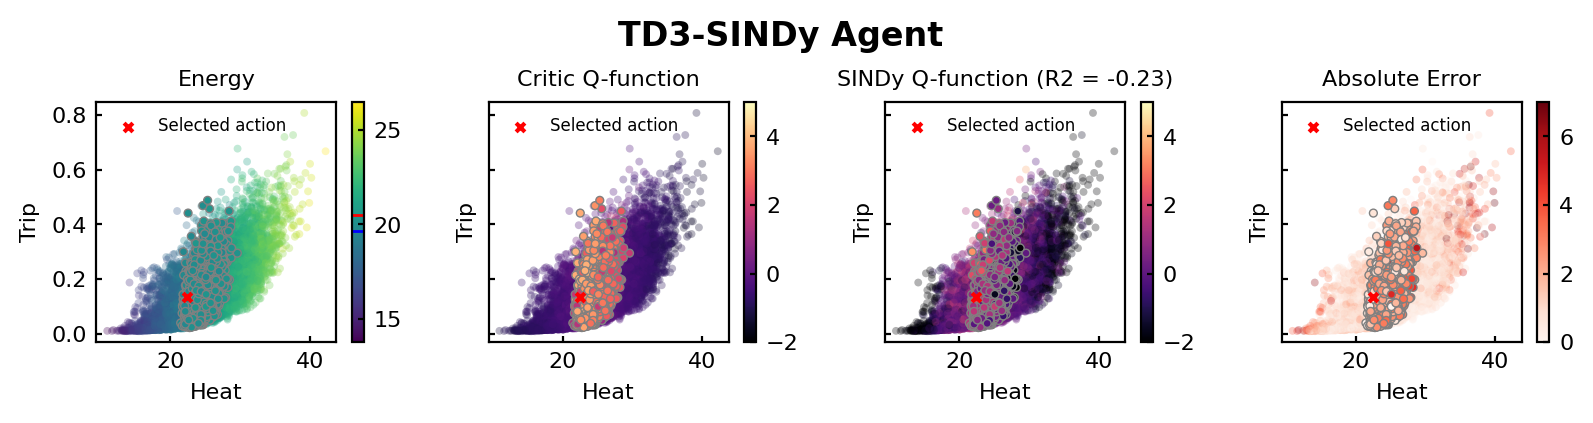

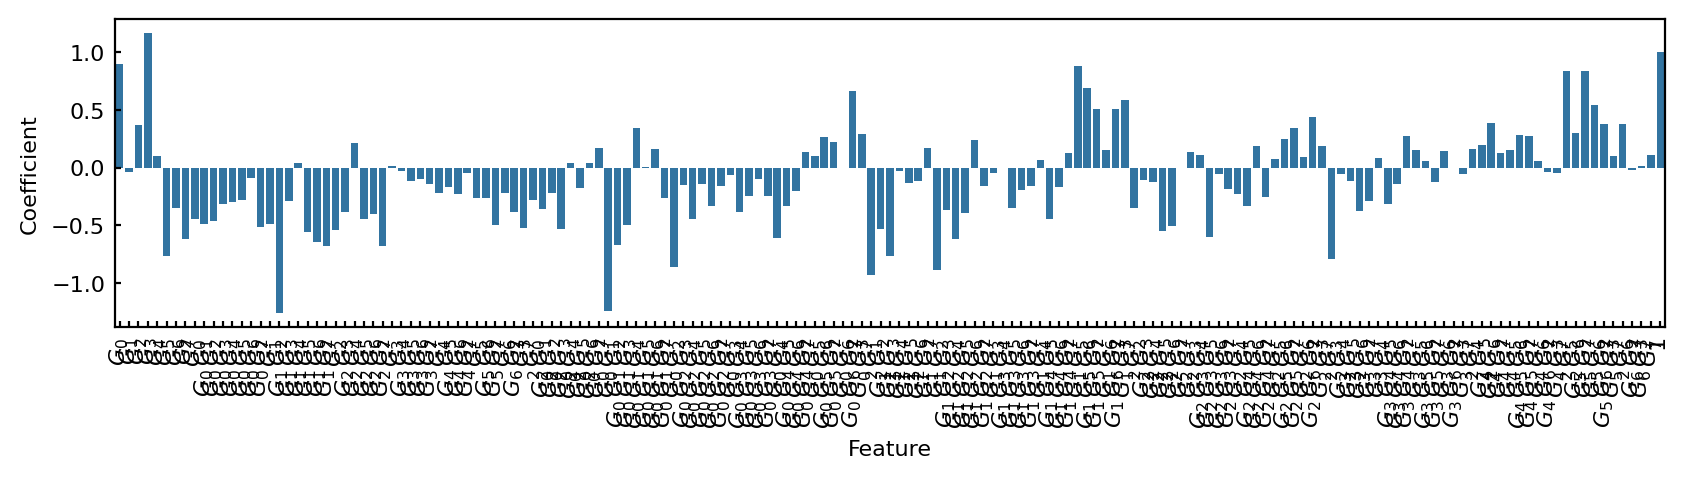

In [48]:
# Agent
models_dir = '/Users/jcolen/Documents/rl_opt_control/models/CEBAF/'
agent_id = 'KerasSINDyCriticTD3-v0'
logdir = glob.glob(f'{models_dir}/{models_subdir}/*{agent_id}*')[0]

agent = agents.make(
    agent_id, 
    env=env, 
    logdir=logdir, 
    cfg=f'{logdir}/cfgs/keras_sindy_critic_td3.cfg'
)

checkpoints = sorted(glob.glob(f'{logdir}/models/epoch_*'))
agent.model_load_path = checkpoints[-1]
print('Loading model from checkpoint: ', os.path.basename(agent.model_load_path))
agent.load()


# Get states and actions
N = 10000
states = np.zeros([N, env.ncavities])
actions = np.random.uniform(size=(N, env.ncavities), low=-1, high=1)
critic_values = agent.critic_model1(states, actions).numpy()

action = agent.actor_model(states[0:1], training=False)
_, _, _, _, info = env.step(action[0])

states_actions = tf.keras.layers.Concatenate(axis=1)([states, actions])
lib_batch = agent.library(states_actions)
sindy_values = agent.critic_sindy(lib_batch).numpy()

from sklearn.metrics import r2_score
score = r2_score(critic_values, sindy_values)
print(f'SINDy model reaches R2 = {score:.2f}')

vmin, vmax = -2, 5

fig, ax = plt.subplots(1, 4, figsize=(8, 2), constrained_layout=True, sharex=True, sharey=True)

plot_states_actions(ax[0], env, states, actions, cmap='viridis')
ax[0].set_title('Energy')

plot_states_actions(ax[1], env, states, actions, color=critic_values, cmap='magma', vmax=vmax, vmin=vmin)
ax[1].set_title('Critic Q-function')

plot_states_actions(ax[2], env, states, actions, color=sindy_values, cmap='magma', vmax=vmax, vmin=vmin)
ax[2].set_title(f'SINDy Q-function (R2 = {score:.2f})')

plot_states_actions(ax[3], env, states, actions, color=np.abs(critic_values-sindy_values), cmap='Reds', vmin=0, vmax=np.abs(vmax-vmin))
ax[3].set_title('Absolute Error')

for a in ax:
    a.scatter(info['heat'], info['trip'], color='red', s=10, marker='x', label='Selected action')
    a.legend(framealpha=0, fontsize=6)

fig.suptitle('TD3-SINDy Agent', fontweight='bold')

# Plot SINDy coefficients
import seaborn as sns
import pandas as pd
feature_names = agent.library.get_feature_names(input_features=[f'A{i:01d}' for i in range(env.ncavities)] + [f'G_{i:01d}' for i in range(env.ncavities)])
feature_names = [f'${fn}$'.replace(' ', '\\,') for fn in feature_names]
mask = np.array(['A' not in fn for fn in feature_names])
df = pd.DataFrame({
    'Coefficient': agent.critic_sindy.coefs[mask].numpy().flatten(),
    'Feature': np.array(feature_names)[mask],
})

fig, ax = plt.subplots(1, 1, figsize=(10, 2))
sns.barplot(data=df, x='Feature', y='Coefficient', ax=ax)
plt.xticks(rotation=90);

KerasSINDyUncertaintyTD3-v0_sindy_beta=1
Loading model from checkpoint:  epoch_9999
SINDy model reaches R2 = 0.95


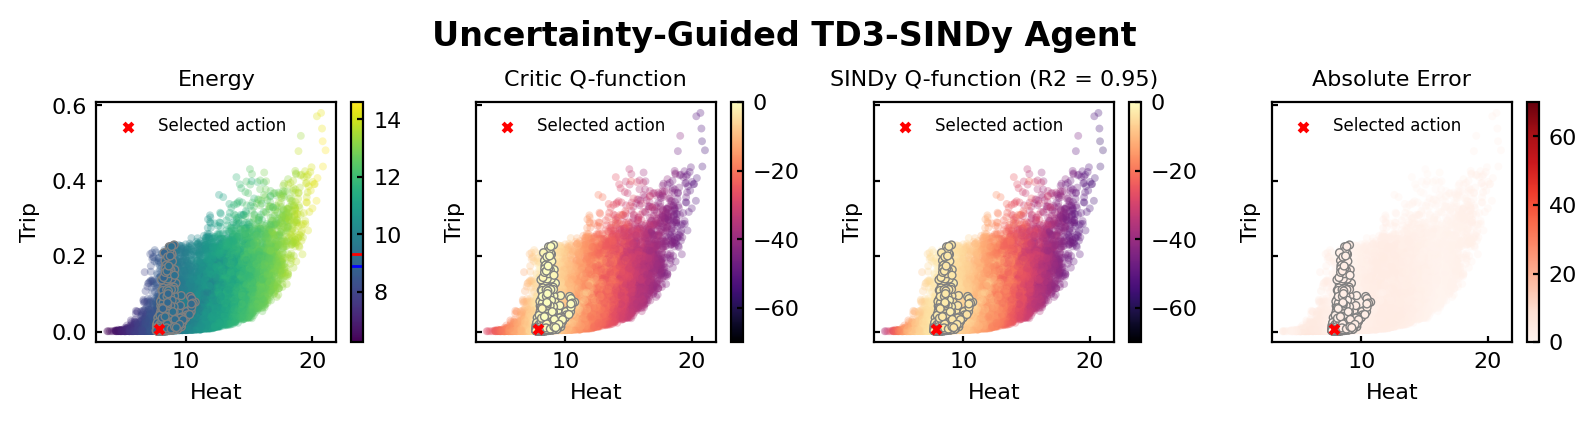

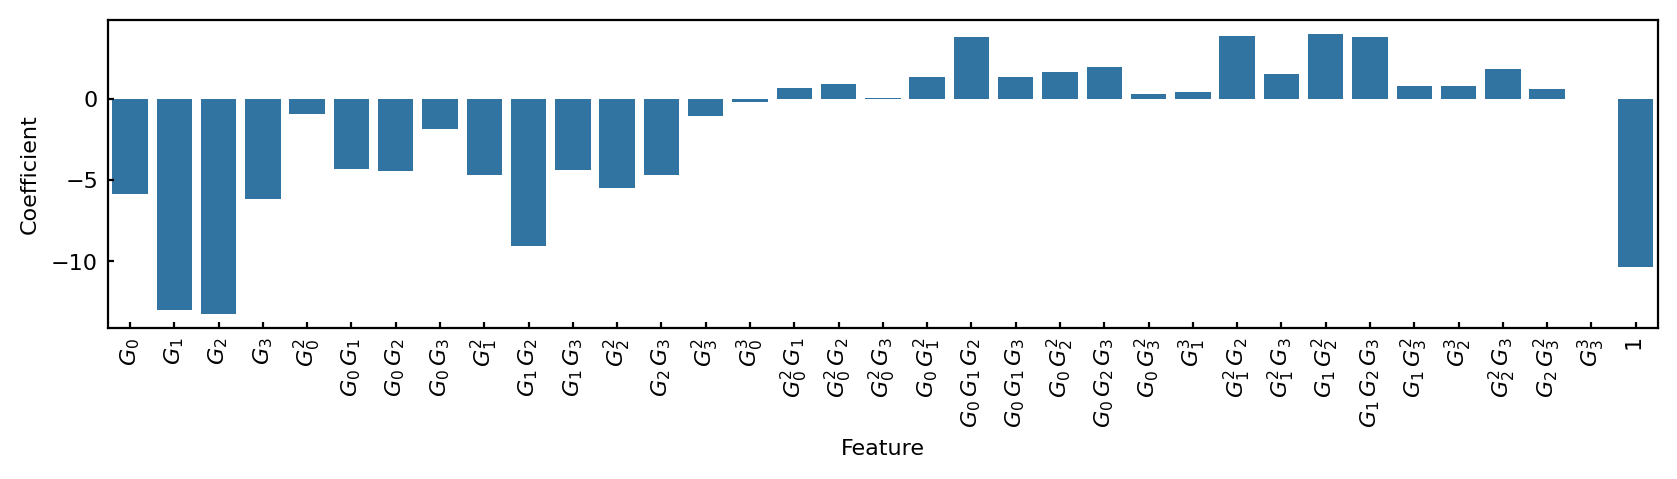

In [26]:
# Agent
models_dir = '/Users/jcolen/Documents/rl_opt_control/models/CEBAF/'
agent_id = 'KerasSINDyUncertaintyTD3-v0'
logdir = glob.glob(f'{models_dir}/{models_subdir}/*{agent_id}*')[0]
print(os.path.basename(logdir))

agent = agents.make(
    agent_id, 
    env=env, 
    logdir=logdir, 
    cfg=f'{logdir}/cfgs/keras_sindy_uncertainty_td3.cfg'
)

checkpoints = sorted(glob.glob(f'{logdir}/models/epoch_*'))
agent.model_load_path = checkpoints[-1]
print('Loading model from checkpoint: ', os.path.basename(agent.model_load_path))
agent.load()


# Get states and actions
N = 10000
states = np.zeros([N, env.ncavities])
actions = np.random.uniform(size=(N, env.ncavities), low=-1, high=1)
critic_values = agent.critic_model1(states, actions).numpy()

action = agent.actor_model(states[0:1], training=False)
_, _, _, _, info = env.step(action[0])

states_actions = tf.keras.layers.Concatenate(axis=1)([states, actions])
lib_batch = agent.library(states_actions)
sindy_values = agent.critic_sindy(lib_batch).numpy()

from sklearn.metrics import r2_score
score = r2_score(critic_values, sindy_values)
print(f'SINDy model reaches R2 = {score:.2f}')

vmin, vmax = -70, 0

fig, ax = plt.subplots(1, 4, figsize=(8, 2), constrained_layout=True, sharex=True, sharey=True)

plot_states_actions(ax[0], env, states, actions, cmap='viridis')
ax[0].set_title('Energy')

plot_states_actions(ax[1], env, states, actions, color=critic_values, cmap='magma', vmax=vmax, vmin=vmin)
ax[1].set_title('Critic Q-function')

plot_states_actions(ax[2], env, states, actions, color=sindy_values, cmap='magma', vmax=vmax, vmin=vmin)
ax[2].set_title(f'SINDy Q-function (R2 = {score:.2f})')

plot_states_actions(ax[3], env, states, actions, color=np.abs(critic_values-sindy_values), cmap='Reds', vmin=0, vmax=np.abs(vmax-vmin))
ax[3].set_title('Absolute Error')

for a in ax:
    a.scatter(info['heat'], info['trip'], color='red', s=10, marker='x', label='Selected action')
    a.legend(framealpha=0, fontsize=6)

fig.suptitle('Uncertainty-Guided TD3-SINDy Agent', fontweight='bold')

# Plot SINDy coefficients
import seaborn as sns
import pandas as pd
feature_names = agent.library.get_feature_names(input_features=[f'A{i:01d}' for i in range(env.ncavities)] + [f'G_{i:01d}' for i in range(env.ncavities)])
feature_names = [f'${fn}$'.replace(' ', '\\,') for fn in feature_names]
mask = np.array(['A' not in fn for fn in feature_names])
df = pd.DataFrame({
    'Coefficient': agent.critic_sindy.coefs[mask].numpy().flatten(),
    'Feature': np.array(feature_names)[mask],
})

fig, ax = plt.subplots(1, 1, figsize=(10, 2))
sns.barplot(data=df, x='Feature', y='Coefficient', ax=ax)
plt.xticks(rotation=90);